# 05_ML_Model_Comparison_Dispersion
Comprehensive ML workflow: SVR, ANN, Random Forest, Gradient Boosting

In [1]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)  

c:\Users\Public\workspace\sh-wave-ml-surrogate\classical_ml


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import models
from ml.models import get_svr, get_ann, get_rf, get_gbr


## Load / Prepare Data
Replace this with your actual dataset

In [3]:
import os
import pandas as pd
from joblib import load

ROOT = os.path.abspath("..")

# Load model and data with basic checks
data_path = os.path.join(ROOT, 'data', 'raw', 'dispersion_vs_L.xlsx')

if not os.path.exists(data_path):
    raise FileNotFoundError(f'Data file not found: {data_path}')

data = pd.read_excel(data_path)

# Inputs
X = data[["kL", "L"]].values

# Output (IMPORTANT)
if 'c_beta' not in data.columns:
    raise KeyError("Column 'c_beta' not found in data")
y = data["c_beta"].values

print(f"Data shape: {X.shape}")

Data shape: (870, 2)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Initialize Models

In [5]:
models = {
    "SVR": get_svr(),
    "ANN": get_ann(),
    "Random Forest": get_rf(),
    "Gradient Boosting": get_gbr()
}


## Train and Evaluate

In [6]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

df_results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
df_results


Training SVR...
Training ANN...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,RMSE,R2
0,SVR,0.006649,0.007336,0.996888
1,ANN,0.033487,0.041695,0.899451
2,Random Forest,0.000932,0.001314,0.999900
3,Gradient Boosting,0.001480,0.001945,0.999781


## Hyperparameter Tuning (GridSearch)

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid_svr = {
    'svr__C': [10, 100],
    'svr__gamma': ['scale', 0.1],
    'svr__epsilon': [0.01, 0.1]
}

grid_svr = GridSearchCV(get_svr(), param_grid_svr, cv=3, scoring='r2', n_jobs=-1)
grid_svr.fit(X_train, y_train)

print("Best SVR Params:", grid_svr.best_params_)
best_svr = grid_svr.best_estimator_


Best SVR Params: {'svr__C': 100, 'svr__epsilon': 0.01, 'svr__gamma': 0.1}


## Dispersion Curve Plot (Actual vs Predicted)

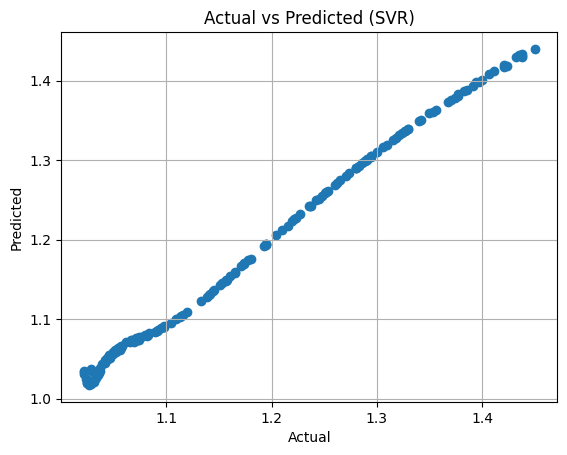

In [8]:
import matplotlib.pyplot as plt

plt.figure()

y_pred_best = best_svr.predict(X_test)

plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (SVR)")
plt.grid()

plt.show()


## Model Comparison Graph

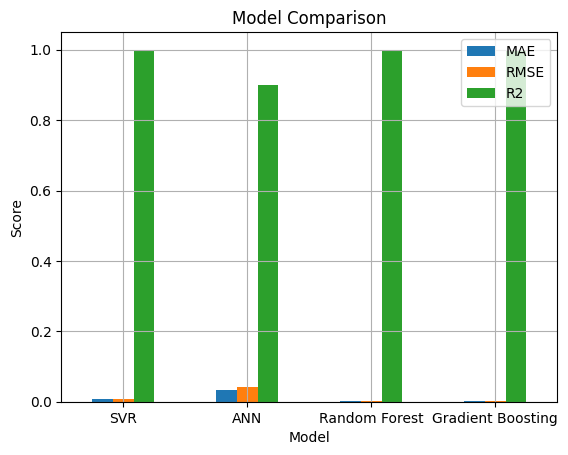

In [9]:
df_results.set_index("Model")[["MAE", "RMSE", "R2"]].plot(kind="bar")

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid()

plt.show()


## Overfitting / Underfitting Analysis

In [ ]:
# models = {
#     "SVR": get_svr(),
#     "ANN": get_ann(),
#     "Random Forest": get_rf(),
#     "Gradient Boosting": get_gbr()
# }


In [16]:
from sklearn.model_selection import learning_curve

import matplotlib.pyplot as plt

model = "ANN"  # you can change model here

In [18]:
def plot_learning_curves(models, X, y):
    from sklearn.model_selection import learning_curve
    import matplotlib.pyplot as plt
    import numpy as np

    for name, model in models.items():
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y,
            cv=5,
            scoring='r2',
            n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5)
        )

        train_mean = train_scores.mean(axis=1)
        test_mean = test_scores.mean(axis=1)

        plt.figure()
        plt.plot(train_sizes, train_mean, label="Train Score")
        plt.plot(train_sizes, test_mean, label="Validation Score")

        plt.title(f"Learning Curve ({name})")
        plt.xlabel("Training Size")
        plt.ylabel("R2 Score")
        plt.legend()
        plt.grid()

        plt.show()

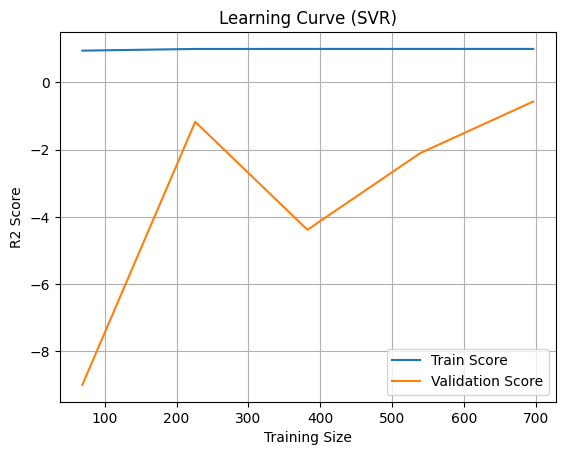

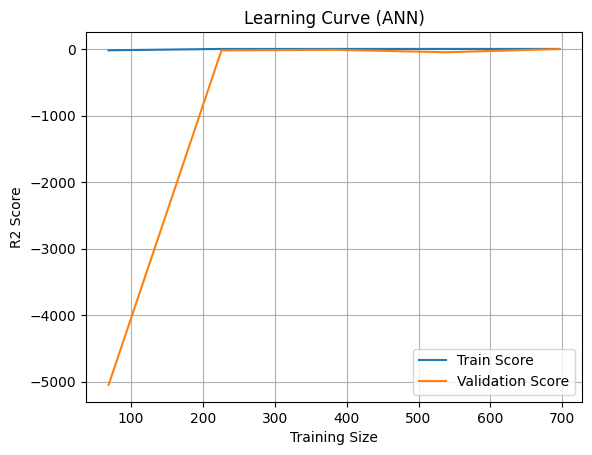

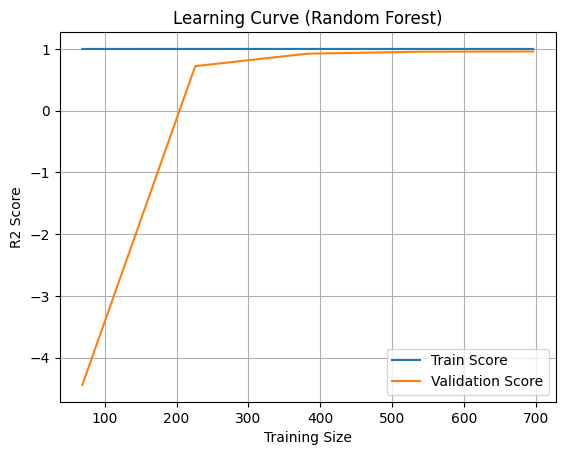

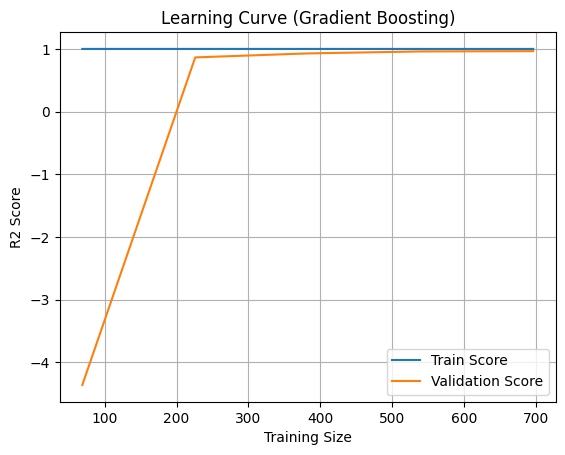

In [ ]:
plot_learning_curves(models, X, y)


## Residual Analysis

In [21]:
def plot_residuals(models, X_train, X_test, y_train, y_test):
    import matplotlib.pyplot as plt

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        residuals = y_test - y_pred

        plt.figure()
        plt.scatter(y_pred, residuals)

        plt.axhline(0)  # reference line
        plt.title(f"Residual Plot ({name})")
        plt.xlabel("Predicted")
        plt.ylabel("Residuals")
        plt.grid()

        plt.show()

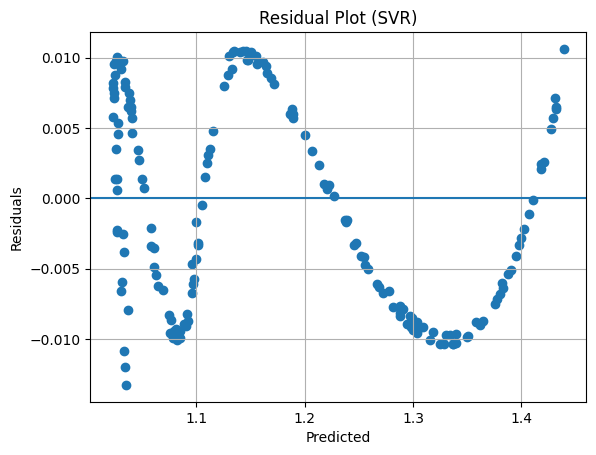

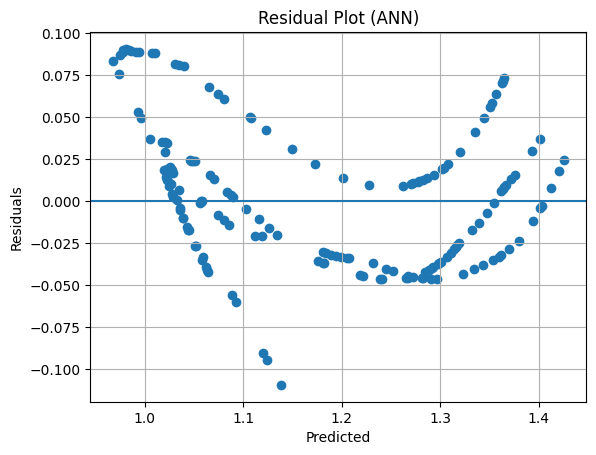

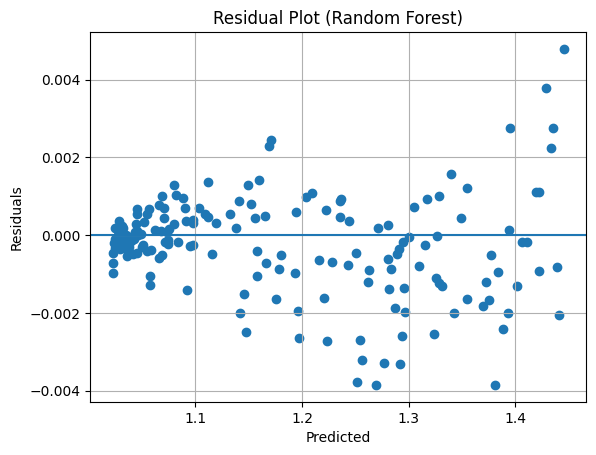

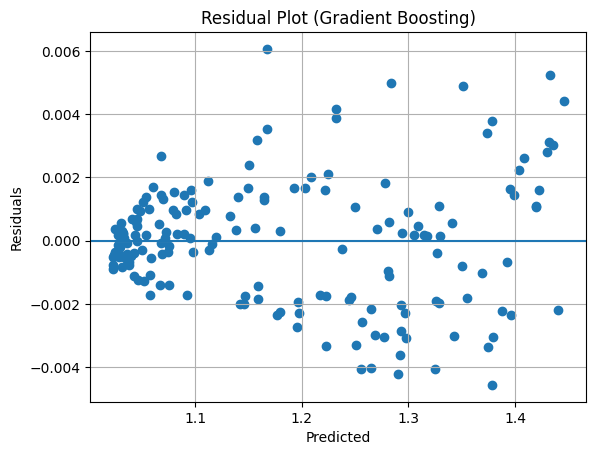

In [22]:
plot_residuals(models, X_train, X_test, y_train, y_test)

## Model Explainability

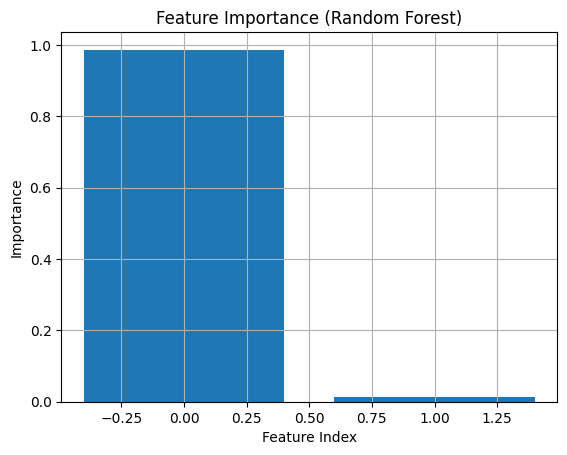

In [12]:
# For tree-based models (RF / GBR)
importances = models["Random Forest"].feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.grid()
plt.show()


### Optional: SHAP Explainability (if installed)

In [13]:
# Uncomment if SHAP is installed
# import shap
# explainer = shap.Explainer(models["Random Forest"], X_train)
# shap_values = explainer(X_test[:100])
# shap.plots.beeswarm(shap_values)


In [23]:
def plot_error_analysis(models, X_train, X_test, y_train, y_test, feature_index=0):
    import matplotlib.pyplot as plt
    import numpy as np

    for name, model in models.items():
        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Residuals
        residuals = y_test - y_pred

        # 🔹 1. Histogram of residuals
        plt.figure()
        plt.hist(residuals, bins=30)
        plt.title(f"Residual Histogram ({name})")
        plt.xlabel("Residual")
        plt.ylabel("Frequency")
        plt.grid()
        plt.show()

        # 🔹 2. Residual vs input (kL)
        kL = X_test[:, feature_index]

        plt.figure()
        plt.scatter(kL, residuals)
        plt.axhline(0)

        plt.title(f"Residual vs kL ({name})")
        plt.xlabel("kL")
        plt.ylabel("Residual")
        plt.grid()
        plt.show()

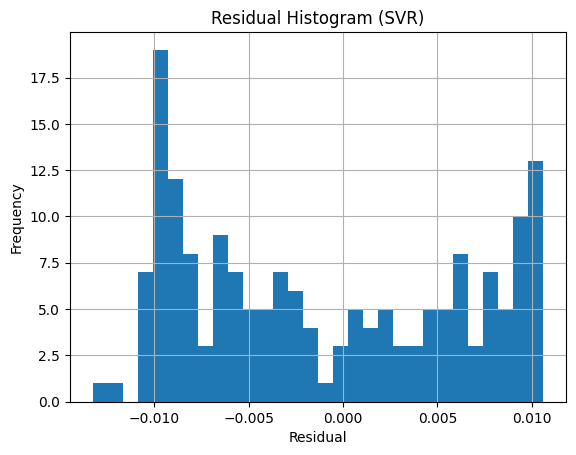

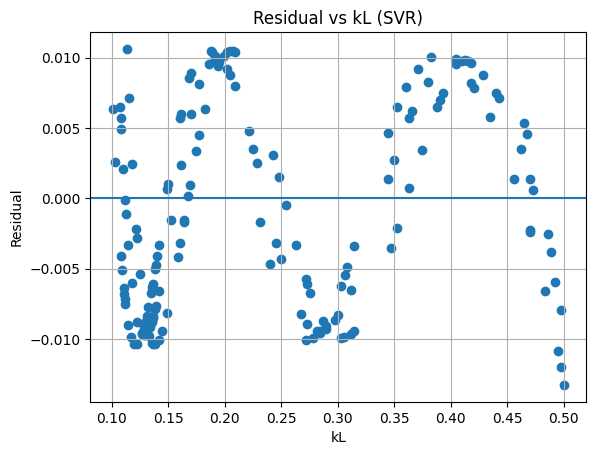

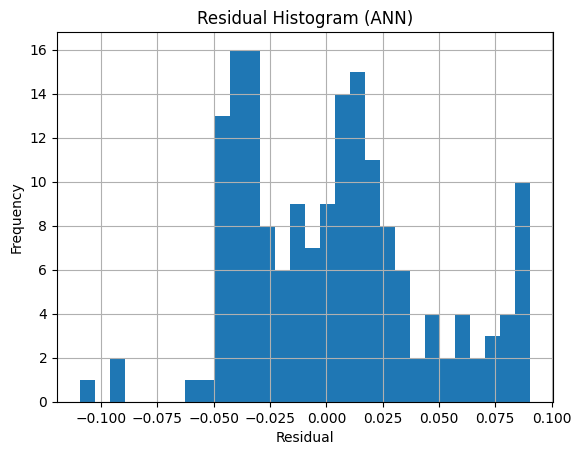

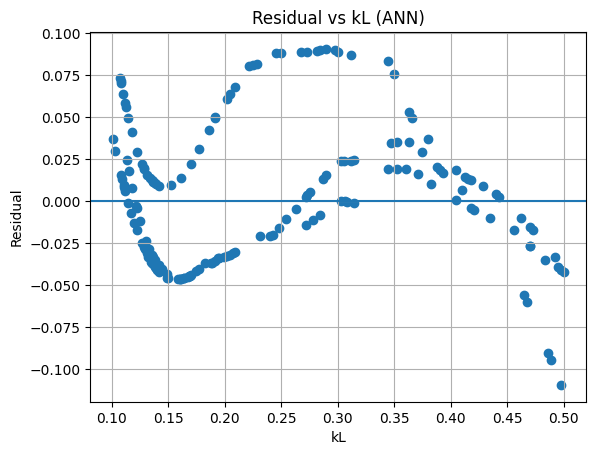

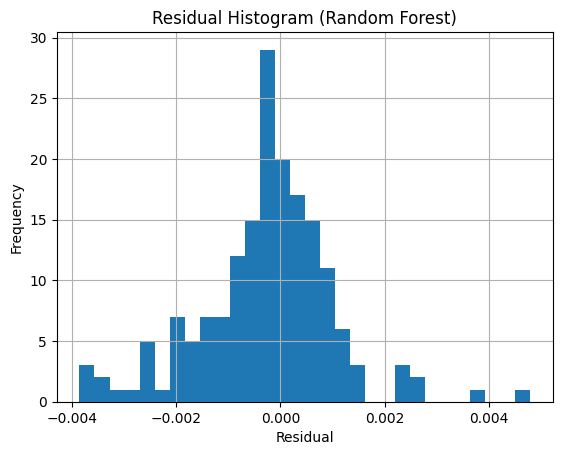

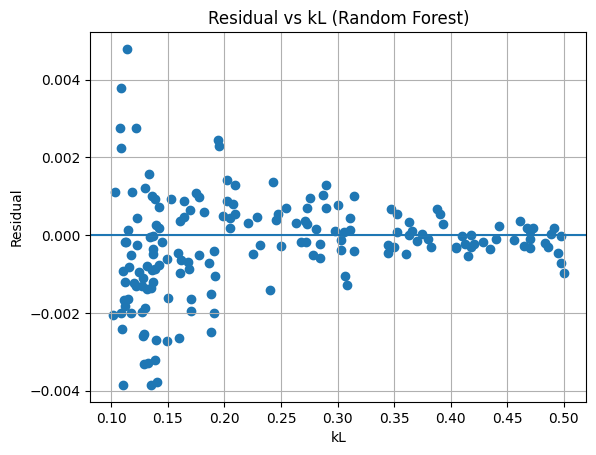

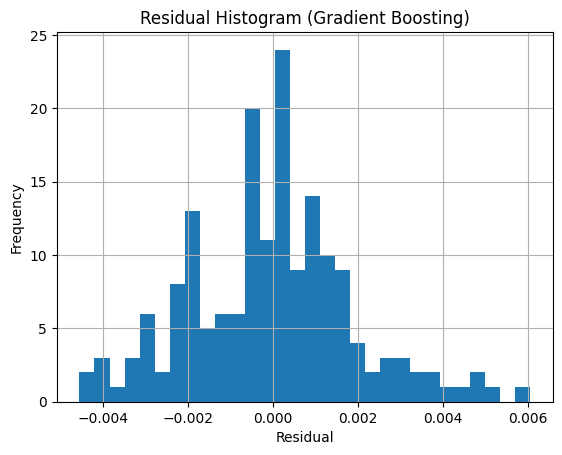

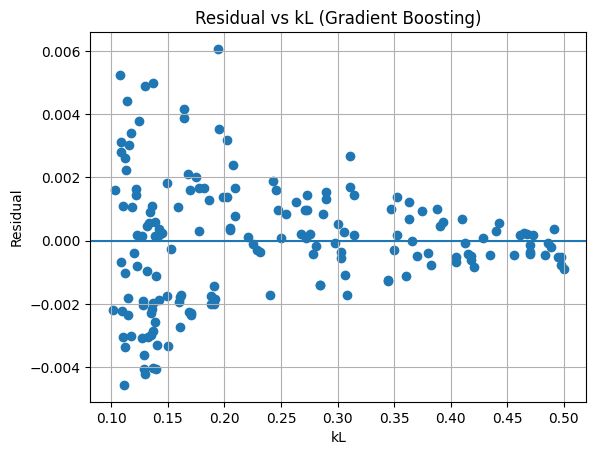

In [24]:
plot_error_analysis(models, X_train, X_test, y_train, y_test)

In [25]:
def plot_feature_importance(models, X_train, y_train, feature_names):
    import matplotlib.pyplot as plt
    
    for name, model in models.items():
        if name in ["Random Forest", "Gradient Boosting"]:
            model.fit(X_train, y_train)
            importances = model.feature_importances_

            plt.figure()
            plt.bar(feature_names, importances)
            plt.title(f"Feature Importance ({name})")
            plt.ylabel("Importance")
            plt.grid()
            plt.show()

In [26]:
def plot_permutation_importance(models, X_test, y_test, feature_names):
    from sklearn.inspection import permutation_importance
    import matplotlib.pyplot as plt

    for name, model in models.items():
        model.fit(X_train, y_train)

        result = permutation_importance(
            model, X_test, y_test,
            n_repeats=10,
            random_state=42,
            n_jobs=-1
        )

        plt.figure()
        plt.bar(feature_names, result.importances_mean)
        plt.title(f"Permutation Importance ({name})")
        plt.ylabel("Importance")
        plt.grid()
        plt.show()

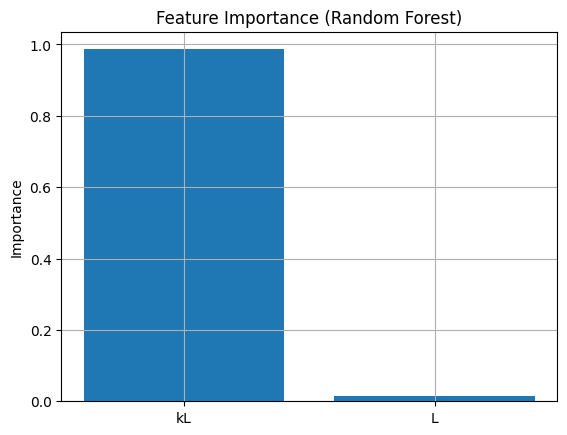

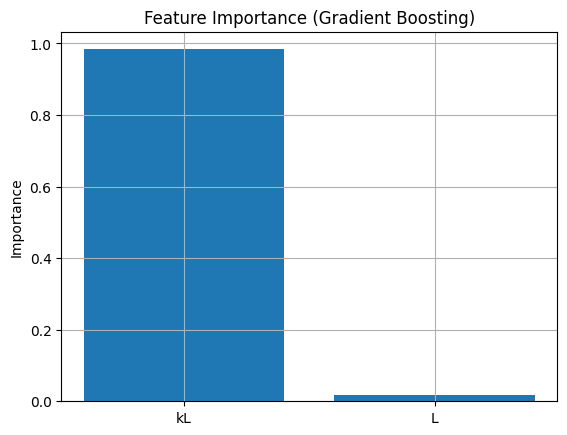

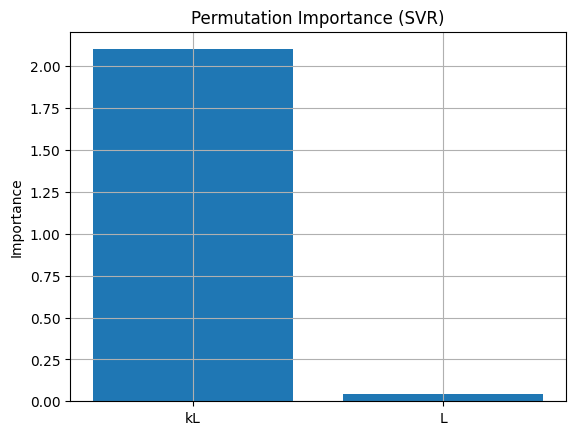

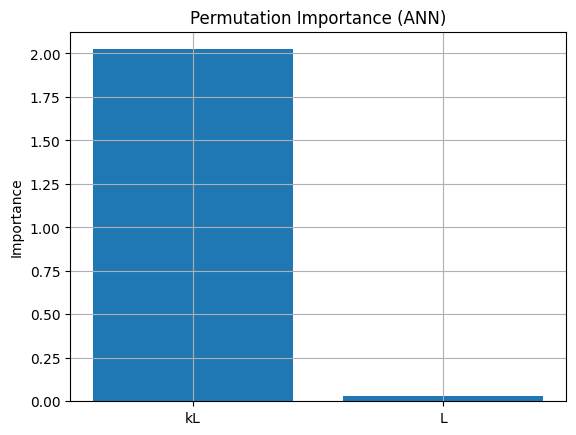

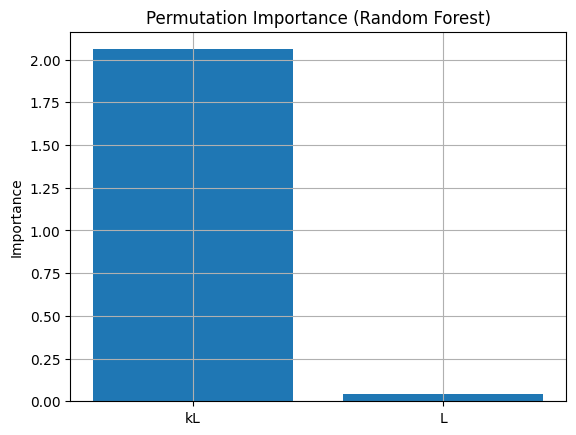

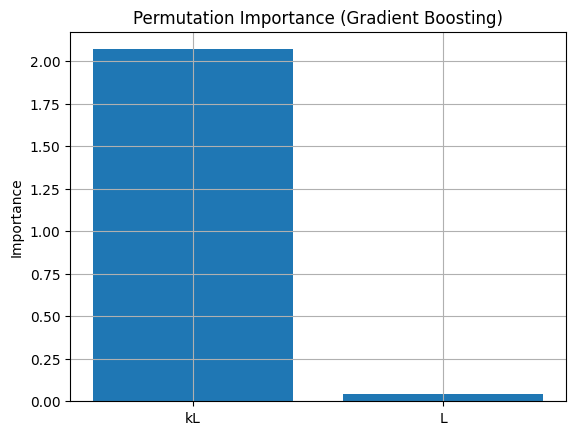

In [27]:
feature_names = ["kL", "L"]  # adjust if needed

plot_feature_importance(models, X_train, y_train, feature_names)
plot_permutation_importance(models, X_test, y_test, feature_names)